In [1]:
# Wolfram Language Imports
from wolframclient.evaluation import WolframLanguageSession
from wolframclient.language import wl, wlexpr
ws = WolframLanguageSession()

In [2]:
# Display Latex
from IPython.display import display, Math

# Display Plots
%matplotlib notebook
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [3]:
def print_tex(expr):
    """Prints an expression in latex"""
    display(Math(expr))

def print_wlresult(expr):
    """Prints a wolfram language result in latex"""
    tex_expr = ws.evaluate(wl.ToString(wl.TeXForm(expr)))
    display(Math(tex_expr))

def print_wlexpr(expr):
    """Prints a wolfram language expression in latex"""
    tex_expr = ws.evaluate(wl.ToString(wl.TeXForm(ws.evaluate(expr))))
    display(Math(tex_expr))
    
def wc(expr):
    """Evaluates an expression, stores, and prints the result"""
    result = ws.evaluate(expr)
    save_expr_str = 'rrr = {}'.format(expr)
    ws.evaluate(save_expr_str)
    print_wlresult(ws.evaluate('rrr'))
    return result

def wplot(filename, command):
    export_expr = 'Export["{}", {}]'.format(filename, command)
    wc(export_expr)
    img = mpimg.imread(filename)
    imgplot = plt.imshow(img)
    plt.show()
    plt.axis('off')
    

print('\nPrinting latex:')
print_tex('\sum_{i=1}^{10} x_i')

print('\nPrinting the result of an evaluated expression:')
print_wlresult(ws.evaluate('x+2+y+3'))

print('\nEvaluating and printing an expression directly:')
print_wlexpr('Sum[x^k, {k, 0, 5}]')

print('\nEvaluating, storing, and printing reults:')
wc('Sum[x^k, {k, 0, 5}]')

print('\nAccessing those results in the variable "rrr":')
wc('rrr*10 + y')


Printing latex:


<IPython.core.display.Math object>


Printing the result of an evaluated expression:


<IPython.core.display.Math object>


Evaluating and printing an expression directly:


...


Evaluating, storing, and printing reults:


<IPython.core.display.Math object>


Accessing those results in the variable "rrr":


<IPython.core.display.Math object>

Plus[Times[10, Plus[1, Global`x, << 2 >>, Power[Global`x, 4], Power[Global`x, 5]]], Global`y]

In [4]:
wc('''
Integrate[x*Exp[-I*x*v]*Exp[Pi/2*x]/(Exp[Pi*x] - 1), x]
''')

<IPython.core.display.Math object>

Times[-2, Power[E, Times[Rational[1, 2], Plus[Pi, Times[Complex[0, -2], Global`v]], Global`x]], Power[Plus[Pi, Times[Complex[0, -2], Global`v]], -2], Plus[Times[Plus[Pi, Times[Complex[0, -2], Global`v]], Global`x, Hypergeometric2F1[1, Plus[Rational[1, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]], Plus[Rational[3, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]], Power[E, Times[Pi, Global`x]]]], Times[-2, HypergeometricPFQ[(1, Plus[Rational[1, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]], Plus[Rational[1, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]]), (Plus[Rational[3, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]], Plus[Rational[3, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]]), Power[E, Times[Pi, Global`x]]]]]]

In [5]:
wc('''
FullSimplify[Integrate[x*Exp[-I*x*v]*Exp[Pi/2*x]/(Exp[Pi*x] - 1), x]]
''')

<IPython.core.display.Math object>

Times[Power[E, Times[Rational[-1, 2], Plus[Pi, Times[Complex[0, 2], Global`v]], Global`x]], Power[Pi, -2], Plus[Times[-1, Power[Power[E, Times[Pi, Global`x]], Plus[Rational[1, 2], Times[Complex[0, 1], Power[Pi, -1], Global`v]]], << 1 >>, Global`x, Beta[Power[E, Times[Pi, Global`x]], Plus[Rational[1, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]], 0]], Times[Power[E, Times[Pi, Global`x]], HurwitzLerchPhi[Power[E, Times[Pi, Global`x]], 2, Plus[Rational[1, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]]]]]]

<IPython.core.display.Javascript object>


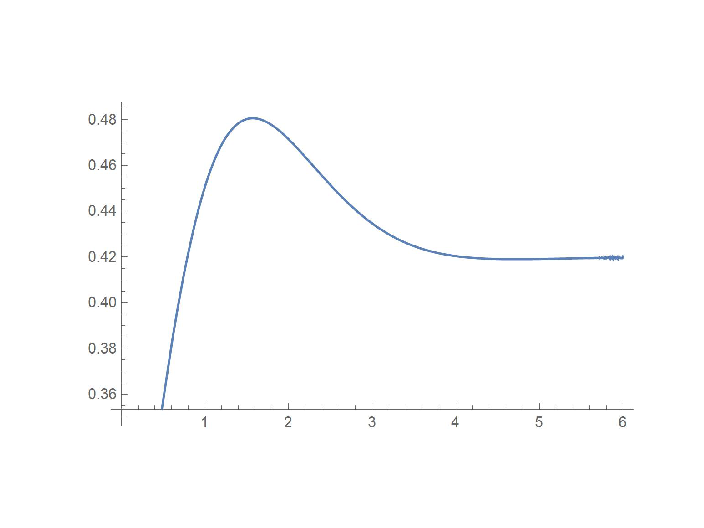

<IPython.core.display.Math object>

In [6]:
plt.figure()
wplot("test.jpg", '''
v1 = 1;
Plot[
{
(1/Pi^2)*
   Re[Exp[-1/2*(Pi + 2*I*v1)*x1]*(
       Exp[Pi*x1]*HurwitzLerchPhi[Exp[Pi*x1], 2, 1/2-I*v1/Pi]
     - Pi*x1*(Exp[Pi*x1])^(1/2 + I*v1/Pi)*Beta[Exp[Pi*x1], 1/2 - I*v1/Pi, 0]
   )]
},
{x1, 0, 6}]
''')

<IPython.core.display.Javascript object>


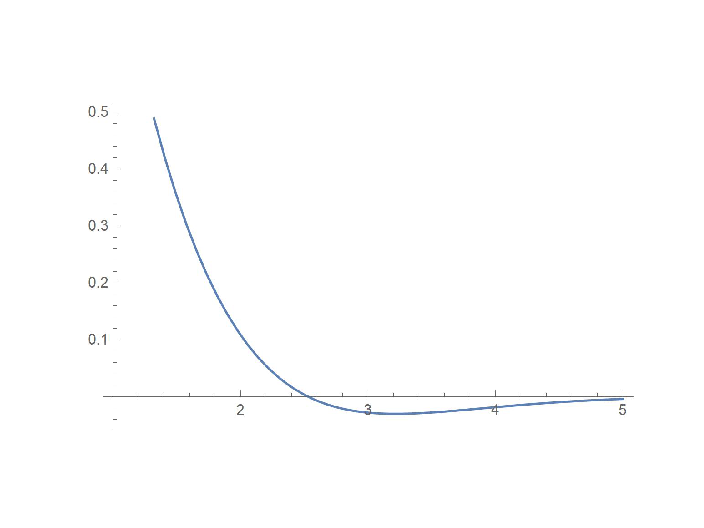

<IPython.core.display.Math object>

In [7]:
plt.figure()
wplot("test.jpg", '''
v1 = 1;
Plot[
{Re[HurwitzLerchPhi[Exp[Pi*x1], 2, 1/2-I*v1/Pi]]},
{x1, 1, 5}]
''')

In [8]:
wc('''
Clear[v,x];
''')

wc('''
Integrate[x*Exp[-I*x*v]*Exp[Pi/2*x]/(Exp[Pi*x] - 1), x]
''')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Times[-2, Power[E, Times[Rational[1, 2], Plus[Pi, Times[Complex[0, -2], Global`v]], Global`x]], Power[Plus[Pi, Times[Complex[0, -2], Global`v]], -2], Plus[Times[Plus[Pi, Times[Complex[0, -2], Global`v]], Global`x, Hypergeometric2F1[1, Plus[Rational[1, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]], Plus[Rational[3, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]], Power[E, Times[Pi, Global`x]]]], Times[-2, HypergeometricPFQ[(1, Plus[Rational[1, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]], Plus[Rational[1, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]]), (Plus[Rational[3, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]], Plus[Rational[3, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]]), Power[E, Times[Pi, Global`x]]]]]]

In [ ]:
wc('''v''')

<IPython.core.display.Javascript object>


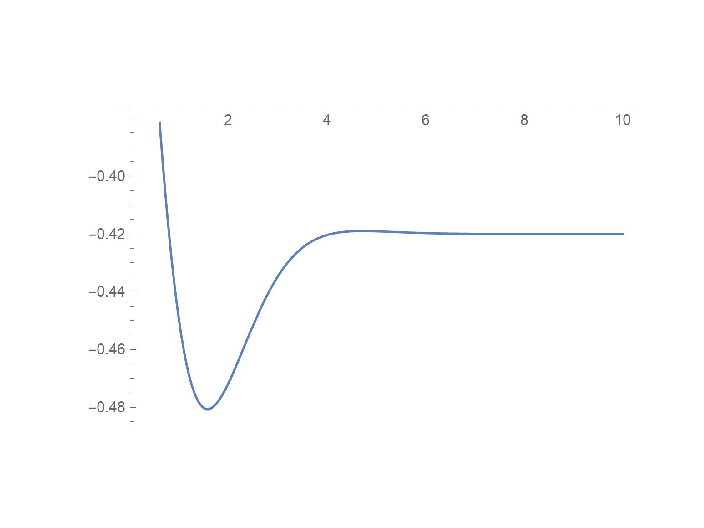

<IPython.core.display.Math object>

In [31]:
plt.figure()
wplot("test.jpg", '''
v1 = 1;
Plot[
{
2*Re[
    Exp[1/2*(Pi-2*I*v1)*x1]*(
        (Pi - 2*I*v1) * x1 * Hypergeometric2F1[1, 1/2 - I*v1/Pi, 3/2 - I*v1/Pi, Exp[Pi*x1]]
        - 2 * HypergeometricPFQ[{1, 1/2 - I*v1/Pi, 1/2 - I*v1/Pi}, {3/2 - I*v1/Pi, 3/2 - I*v1/Pi}, Exp[Pi*x1]]
    ) / (Pi - 2*I*v1)^2
]
},
{x1, 0, 10}]
''')

<IPython.core.display.Javascript object>


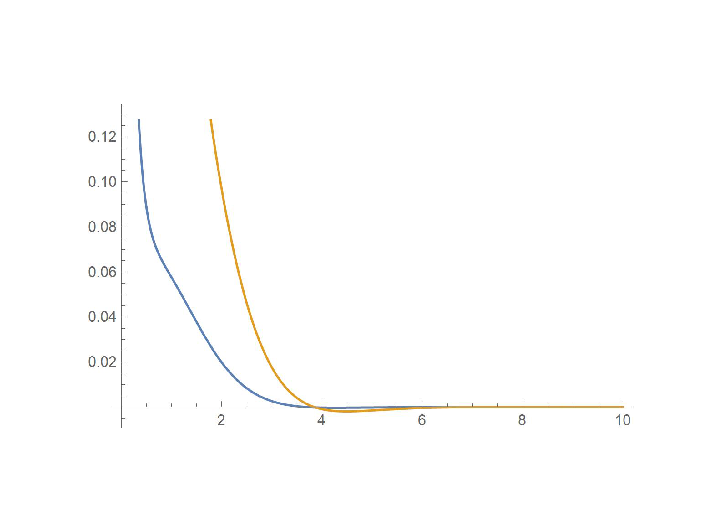

<IPython.core.display.Math object>

In [35]:
plt.figure()
wplot("test.jpg", '''
v1 = 1;
Plot[
{
    Re[Hypergeometric2F1[1, 1/2 - I*v1/Pi, 3/2 - I*v1/Pi, Exp[Pi*x1]]],
    Re[HypergeometricPFQ[{1, 1/2 - I*v1/Pi, 1/2 - I*v1/Pi}, {3/2 - I*v1/Pi, 3/2 - I*v1/Pi}, Exp[Pi*x1]]]
},
{x1, 0, 10}]
''')

<IPython.core.display.Javascript object>


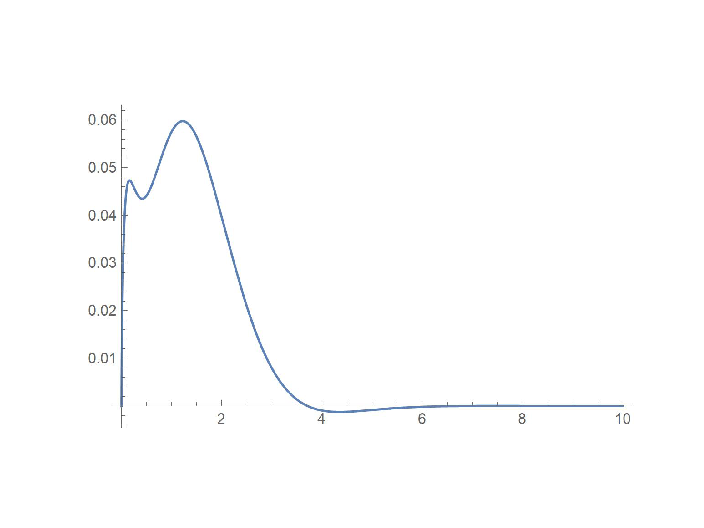

<IPython.core.display.Math object>

In [36]:
plt.figure()
wplot("test.jpg", '''
v1 = 1;
Plot[
{
    Re[x1 * Hypergeometric2F1[1, 1/2 - I*v1/Pi, 3/2 - I*v1/Pi, Exp[Pi*x1]]]
},
{x1, 0, 10}]
''')

<IPython.core.display.Javascript object>


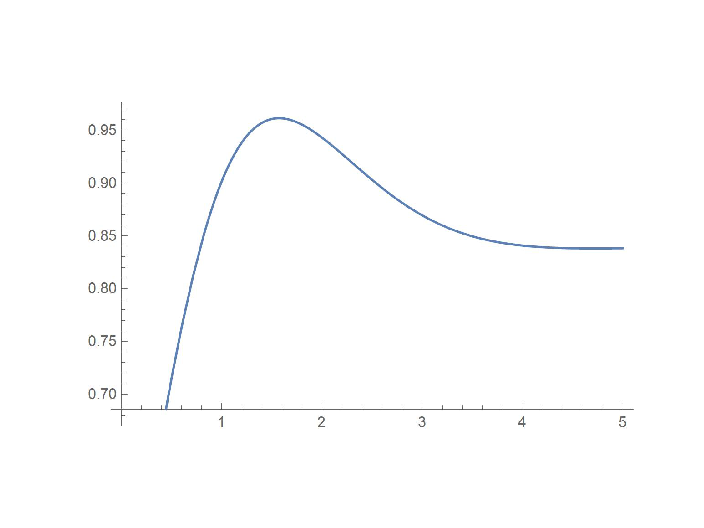

<IPython.core.display.Math object>

In [61]:
plt.figure()
wplot("test.jpg", '''
v1 = 1;
Plot[
{
Re[
    -
    2 * Exp[1/2*(Pi-2*I*v1)*x1]*(
            (Pi - 2*I*v1) * x1 * Hypergeometric2F1[1, 1/2 - I*v1/Pi, 3/2 - I*v1/Pi, Exp[Pi*x1]]
            - 2 * HypergeometricPFQ[{1, 1/2 - I*v1/Pi, 1/2 - I*v1/Pi}, {3/2 - I*v1/Pi, 3/2 - I*v1/Pi}, Exp[Pi*x1]]
        ) / (Pi - 2*I*v1)^2
    -
    2 * Exp[1/2*(Pi+2*I*v1)*x1]*(
            (Pi + 2*I*v1) * x1 * Hypergeometric2F1[1, 1/2 + I*v1/Pi, 3/2 + I*v1/Pi, Exp[Pi*x1]]
            - 2 * HypergeometricPFQ[{1, 1/2 + I*v1/Pi, 1/2 + I*v1/Pi}, {3/2 + I*v1/Pi, 3/2 + I*v1/Pi}, Exp[Pi*x1]]
        ) / (Pi + 2*I*v1)^2
]
},
{x1, 0, 5}]
''')

<IPython.core.display.Javascript object>


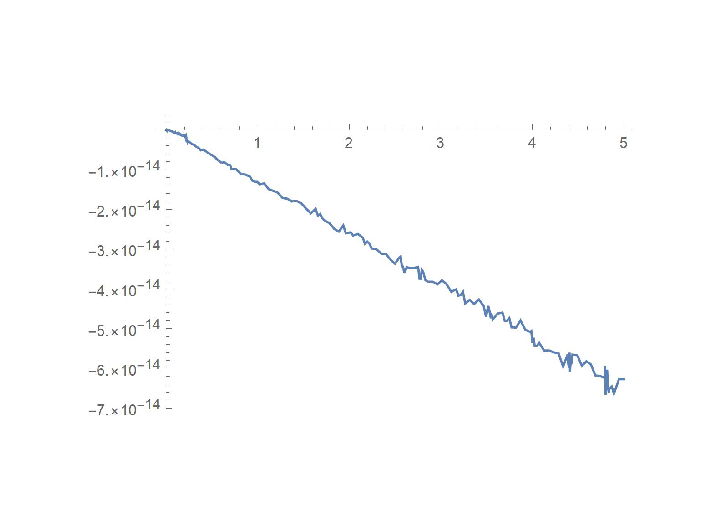

<IPython.core.display.Math object>

In [60]:
plt.figure()
wplot("test.jpg", '''
v1 = 1;
Plot[
{
Im[
    -
    2*(
        Exp[1/2*(Pi-2*I*v1)*x1]*(
            (Pi - 2*I*v1) * x1 * Hypergeometric2F1[1, 1/2 - I*v1/Pi, 3/2 - I*v1/Pi, Exp[Pi*x1]]
            - 2 * HypergeometricPFQ[{1, 1/2 - I*v1/Pi, 1/2 - I*v1/Pi}, {3/2 - I*v1/Pi, 3/2 - I*v1/Pi}, Exp[Pi*x1]]
        ) / (Pi - 2*I*v1)^2
    )
    -
    2*(
        Exp[1/2*(Pi+2*I*v1)*x1]*(
            (Pi + 2*I*v1) * x1 * Hypergeometric2F1[1, 1/2 + I*v1/Pi, 3/2 + I*v1/Pi, Exp[Pi*x1]]
            - 2 * HypergeometricPFQ[{1, 1/2 + I*v1/Pi, 1/2 + I*v1/Pi}, {3/2 + I*v1/Pi, 3/2 + I*v1/Pi}, Exp[Pi*x1]]
        ) / (Pi + 2*I*v1)^2
    )
]
},
{x1, 0, 5}]
''')

In [54]:
wc('''
Clear[v,x];
''')

wc('''
Integrate[x*Csch[Pi/2*x]*Cos[x*v], x]
''')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Plus[Times[-2, Power[E, Times[Rational[1, 2], Plus[Pi, Times[Complex[0, -2], Global`v]], Global`x]], Power[Plus[Pi, Times[Complex[0, -2], Global`v]], -2], Plus[Times[Plus[Pi, Times[Complex[0, -2], Global`v]], Global`x, Hypergeometric2F1[1, Plus[Rational[1, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]], Plus[Rational[3, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]], Power[E, Times[Pi, Global`x]]]], Times[-2, HypergeometricPFQ[(1, Plus[Rational[1, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]], Plus[Rational[1, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]]), (Plus[Rational[3, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]], Plus[Rational[3, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]]), Power[E, Times[Pi, Global`x]]]]]], Times[-2, Power[E, Times[Rational[1, 2], Plus[Pi, Times[Complex[0, 2], Global`v]], Global`x]], Power[Plus[Pi, Times[Complex[0, 2], Global`v]], -2], Plus[Times[Plus[Pi, Times[Complex[0, 2], Global`v]], Global`x, Hypergeometric2F1[1, Plus[

<IPython.core.display.Javascript object>


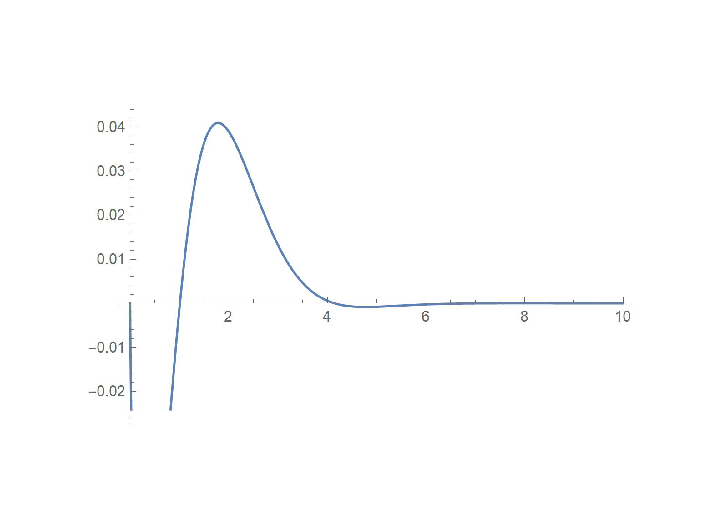

<IPython.core.display.Math object>

In [63]:
plt.figure()
wplot("test.jpg", '''
v1 = 1;
Plot[
{
Re[
    -
    2*(
        Exp[1/2*(Pi-2*I*v1)*x1]*(
            (Pi - 2*I*v1) * x1 * Hypergeometric2F1[1, 1/2 - I*v1/Pi, 3/2 - I*v1/Pi, Exp[Pi*x1]]
        ) / (Pi - 2*I*v1)^2
    )
]
},
{x1, 0, 10}]
''')

<IPython.core.display.Javascript object>


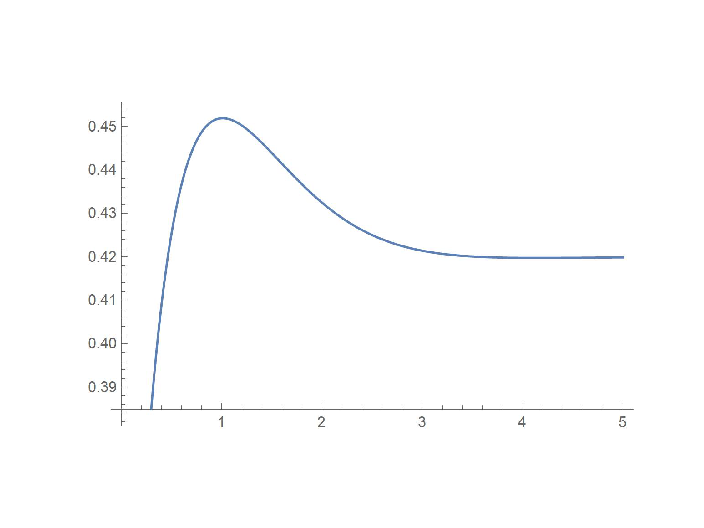

<IPython.core.display.Math object>

In [64]:
plt.figure()
wplot("test.jpg", '''
v1 = 1;
Plot[
{
Re[
    -
    2*(
        Exp[1/2*(Pi-2*I*v1)*x1]*(
            - 2 * HypergeometricPFQ[{1, 1/2 - I*v1/Pi, 1/2 - I*v1/Pi}, {3/2 - I*v1/Pi, 3/2 - I*v1/Pi}, Exp[Pi*x1]]
        ) / (Pi - 2*I*v1)^2
    )
]
},
{x1, 0, 5}]
''')

In [66]:
wc('''
Limit[
    Exp[1/2*(Pi-2*I*v)*x]*(
                - 2 * HypergeometricPFQ[{1, 1/2 - I*v/Pi, 1/2 - I*v/Pi}, {3/2 - I*v/Pi, 3/2 - I*v/Pi}, Exp[Pi*x]]
    ) / (Pi - 2*I*v)^2,
    x -> Infinity
]
''')

<IPython.core.display.Math object>

Limit[Times[-2, Power[E, Times[Rational[1, 2], Plus[Pi, Times[Complex[0, -2], Global`v]], Global`x]], Power[Plus[Pi, Times[Complex[0, -2], Global`v]], -2], HypergeometricPFQ[(1, Plus[Rational[1, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]], Plus[Rational[1, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]]), (Plus[Rational[3, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]], Plus[Rational[3, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]]), Power[E, Times[Pi, Global`x]]]], Rule[Global`x, DirectedInfinity[1]]]

In [67]:
wc('''
Limit[
    HypergeometricPFQ[{1, 1/2 - I*v/Pi, 1/2 - I*v/Pi}, {3/2 - I*v/Pi, 3/2 - I*v/Pi}, Exp[Pi*x]],
    x -> Infinity
]
''')

<IPython.core.display.Math object>

Limit[Times[-2, HypergeometricPFQ[(1, Plus[Rational[1, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]], Plus[Rational[1, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]]), (Plus[Rational[3, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]], Plus[Rational[3, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]]), Power[E, Times[Pi, Global`x]]]], Rule[Global`x, DirectedInfinity[1]]]

In [69]:
wc('''
Limit[
    Exp[1/2*(Pi - 2*I*v)*x],
    x -> Infinity
]
''')

<IPython.core.display.Math object>

ConditionalExpression[DirectedInfinity[1], And[Element[Times[Complex[0, -2], Global`v], Reals], Less[Plus[Times[-1, Pi], Times[Complex[0, 2], Global`v]], 0]]]

<IPython.core.display.Javascript object>


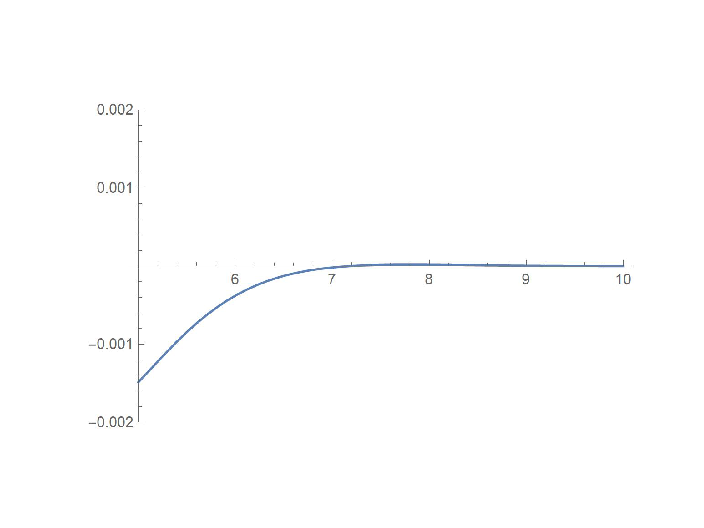

<IPython.core.display.Math object>

In [77]:
plt.figure()
wplot("test.jpg",
'''
Plot[
{
    Re[HypergeometricPFQ[{1, 1/2 - I*v1/Pi, 1/2 - I*v1/Pi}, {3/2 - I*v1/Pi, 3/2 - I*v1/Pi}, Exp[Pi*x1]]]
},
{x1, 5, 10},
PlotRange -> {-0.002, 0.002}
]
''')

In [78]:
wc('''
Clear[v,x];
''')

wc('''
FullSimplify[Integrate[x*Csch[Pi/2*x]*Cos[x*v], x]]
''')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Times[Power[E, Times[Rational[1, 2], Plus[Pi, Times[Complex[0, -2], Global`v]], Global`x]], Power[Pi, -2], Plus[Times[-1, Power[Power[E, Times[Pi, Global`x]], Plus[Rational[-1, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]]], << 1 >>, Global`x, Plus[Times[Power[Power[E, Times[Pi, Global`x]], Times[Complex[0, 2], Power[Pi, -1], Global`v]], Beta[Power[E, Times[Pi, Global`x]], Plus[Rational[1, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]], 0]], Times[Power[E, Times[Complex[0, 2], Global`v, Global`x]], Beta[Power[E, Times[Pi, Global`x]], Plus[Rational[1, 2], Times[Complex[0, 1], Power[Pi, -1], Global`v]], 0]]]], HurwitzLerchPhi[Power[E, Times[Pi, Global`x]], 2, Plus[Rational[1, 2], Times[Complex[0, -1], Power[Pi, -1], Global`v]]], Times[Power[E, Times[Complex[0, 2], Global`v, Global`x]], HurwitzLerchPhi[Power[E, Times[Pi, Global`x]], 2, Plus[Rational[1, 2], Times[Complex[0, 1], Power[Pi, -1], Global`v]]]]]]

<IPython.core.display.Javascript object>


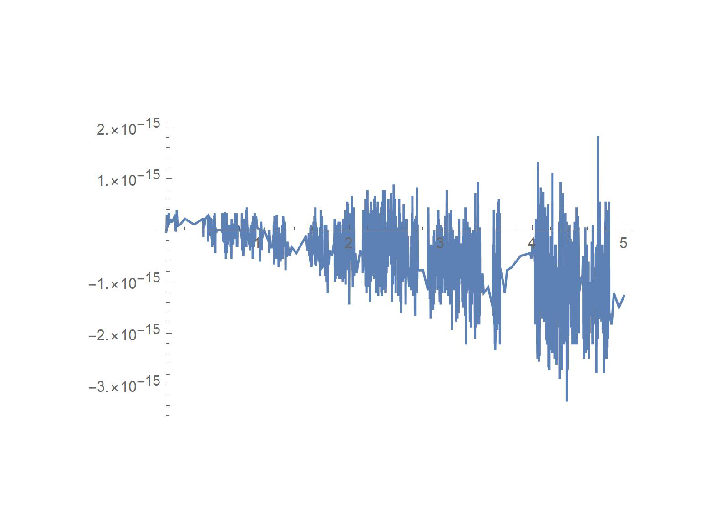

<IPython.core.display.Math object>

In [83]:
plt.figure()
wplot("test.jpg", '''
v1 = 1;
Plot[
{
Re[
    -
    2 * Exp[1/2*(Pi-2*I*v1)*x1]*(
            (Pi - 2*I*v1) * x1 * Hypergeometric2F1[1, 1/2 - I*v1/Pi, 3/2 - I*v1/Pi, Exp[Pi*x1]]
            - 2 * HypergeometricPFQ[{1, 1/2 - I*v1/Pi, 1/2 - I*v1/Pi}, {3/2 - I*v1/Pi, 3/2 - I*v1/Pi}, Exp[Pi*x1]]
        ) / (Pi - 2*I*v1)^2
    +
    2 * Exp[1/2*(Pi+2*I*v1)*x1]*(
            (Pi + 2*I*v1) * x1 * Hypergeometric2F1[1, 1/2 + I*v1/Pi, 3/2 + I*v1/Pi, Exp[Pi*x1]]
            - 2 * HypergeometricPFQ[{1, 1/2 + I*v1/Pi, 1/2 + I*v1/Pi}, {3/2 + I*v1/Pi, 3/2 + I*v1/Pi}, Exp[Pi*x1]]
        ) / (Pi + 2*I*v1)^2
]
},
{x1, 0, 5}]
''')

<IPython.core.display.Javascript object>


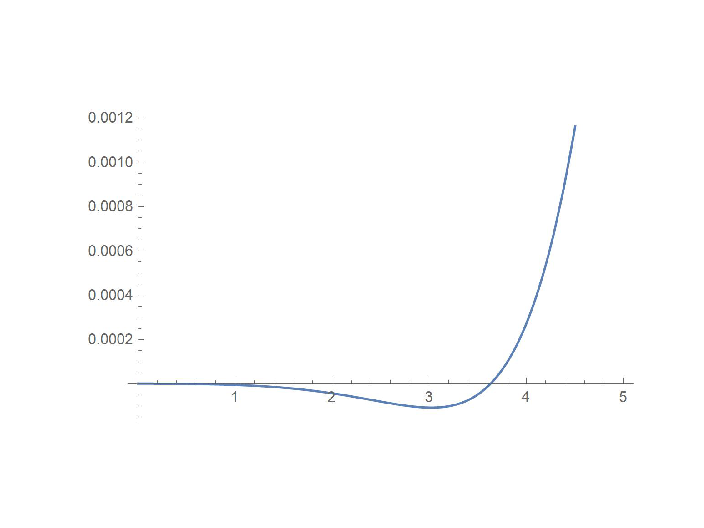

<IPython.core.display.Math object>

In [80]:
plt.figure()
wplot("test.jpg", '''
v1 = 1;
sigma = 10;
Plot[
{
Re[
    -
    2 * Exp[1/2*(Pi-2*I*v1)*x1]*(
            (Pi - 2*I*v1) * x1 * Hypergeometric2F1[1, 1/2 - I*v1/Pi, 3/2 - I*v1/Pi, Exp[Pi*sigma]]
            - 2 * HypergeometricPFQ[{1, 1/2 - I*v1/Pi, 1/2 - I*v1/Pi}, {3/2 - I*v1/Pi, 3/2 - I*v1/Pi}, Exp[Pi*sigma]]
        ) / (Pi - 2*I*v1)^2
    -
    2 * Exp[1/2*(Pi+2*I*v1)*x1]*(
            (Pi + 2*I*v1) * x1 * Hypergeometric2F1[1, 1/2 + I*v1/Pi, 3/2 + I*v1/Pi, Exp[Pi*sigma]]
            - 2 * HypergeometricPFQ[{1, 1/2 + I*v1/Pi, 1/2 + I*v1/Pi}, {3/2 + I*v1/Pi, 3/2 + I*v1/Pi}, Exp[Pi*sigma]]
        ) / (Pi + 2*I*v1)^2
]
},
{x1, 0, 5}]
''')

In [82]:
wc('''
Limit[
    HypergeometricPFQ[{1, 1/2 - I*v1/Pi, 1/2 - I*v1/Pi}, {3/2 - I*v1/Pi, 3/2 - I*v1/Pi}, Exp[Pi*s]],
    s -> Infinity
]
''')

<IPython.core.display.Math object>

Limit[HypergeometricPFQ[(1, Plus[Rational[1, 2], Times[Complex[0, -1], Power[Pi, -1]]], Plus[Rational[1, 2], Times[Complex[0, -1], Power[Pi, -1]]]), (Plus[Rational[3, 2], Times[Complex[0, -1], Power[Pi, -1]]], Plus[Rational[3, 2], Times[Complex[0, -1], Power[Pi, -1]]]), Power[E, Times[Pi, Global`s]]], Rule[Global`s, DirectedInfinity[1]]]

In [ ]:
ws.stop()